# FULL Clustering Pipeline Notebook (Original Logic Preserved)

Notebook này:
- Giữ nguyên 100% pipeline gốc
- Không lược bỏ bất kỳ figure nào
- Fix lỗi exit()
- Fix DBSCAN eps hardcode
- Fix heatmap magnitude distortion
- Fix sai tên file error message


In [33]:
import sys

In [34]:
# 1. IMPORT & SETUP

In [35]:
import sys
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import hdbscan

from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
try:
    # Hỗ trợ cho scikit-learn >= 1.3
    from sklearn.cluster import HDBSCAN
except ImportError:
    # Nếu dùng scikit-learn cũ, bạn cần chạy: pip install hdbscan
    from hdbscan import HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.neighbors import NearestNeighbors

# Cấu hình vẽ đồ thị cho Paper
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [36]:
# 2. LOAD DATA

In [37]:
print("--- 1. Loading Data ---")
try:
    df = pd.read_csv(r"D:/Clustering/Clustering/Clustering/cs-training.csv")
    if df.columns[0].startswith('Unnamed'):
        df = df.iloc[:, 1:]
except FileNotFoundError:
    print("Error: File 'cs-training.csv' not found. Please ensure the file exists.")
    sys.exit()

TARGET_COL = "SeriousDlqin2yrs"
if TARGET_COL in df.columns:
    y_true_full = df[TARGET_COL]
    X_full = df.drop(columns=[TARGET_COL])
else:
    print(f"Error: Target column '{TARGET_COL}' not found.")
    sys.exit()

print(f"Original Shape: {df.shape}")

--- 1. Loading Data ---
Original Shape: (150000, 11)


In [38]:
# 3. FIGURE A: RAW DATA DIAGNOSTICS (EDA)

--- 2. Generating EDA Visualizations ---


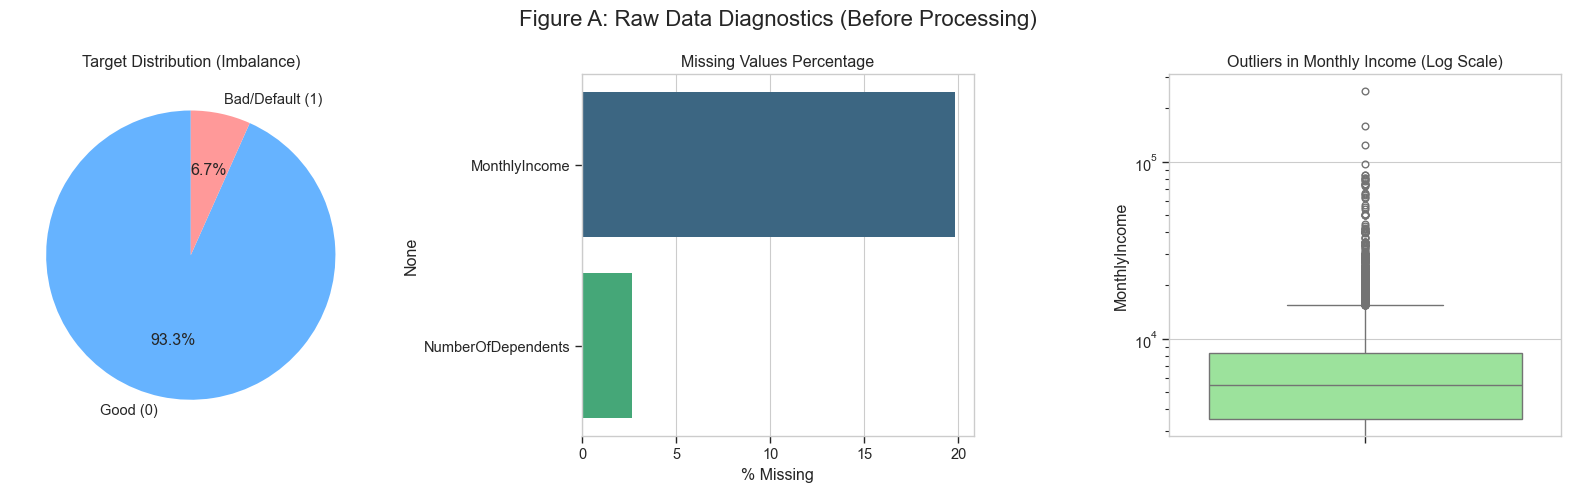

In [39]:
print("--- 2. Generating EDA Visualizations ---")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3.1 Target Distribution
target_counts = df[TARGET_COL].value_counts()
axes[0].pie(target_counts, labels=['Good (0)', 'Bad/Default (1)'], 
            autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0].set_title("Target Distribution (Imbalance)")

# 3.2 Missing Values
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
if not missing_data.empty:
    sns.barplot(x=missing_data.values, y=missing_data.index, ax=axes[1], palette="viridis")
    axes[1].set_xlabel("% Missing")
    axes[1].set_title("Missing Values Percentage")
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center')

# 3.3 Outliers (Boxplot)
sns.boxplot(y=df['MonthlyIncome'].dropna().sample(min(10000, len(df))), ax=axes[2], color='lightgreen')
axes[2].set_yscale('log') 
axes[2].set_title("Outliers in Monthly Income (Log Scale)")

plt.suptitle("Figure A: Raw Data Diagnostics (Before Processing)", fontsize=16)
plt.tight_layout()
plt.savefig("figA_raw_data_diagnostics.png", dpi=150)
plt.show()
plt.close()

In [40]:
# 4. PREPROCESSING

In [41]:
print("--- 3. Preprocessing Data ---")
X_full["MonthlyIncome"] = X_full["MonthlyIncome"].fillna(X_full["MonthlyIncome"].median())
X_full["NumberOfDependents"] = X_full["NumberOfDependents"].fillna(X_full["NumberOfDependents"].median())

lower = X_full.quantile(0.01)
upper = X_full.quantile(0.99)
X_full = X_full.clip(lower=lower, upper=upper, axis=1)

--- 3. Preprocessing Data ---


In [42]:
# 5. FIGURE 1: CORRELATION HEATMAP

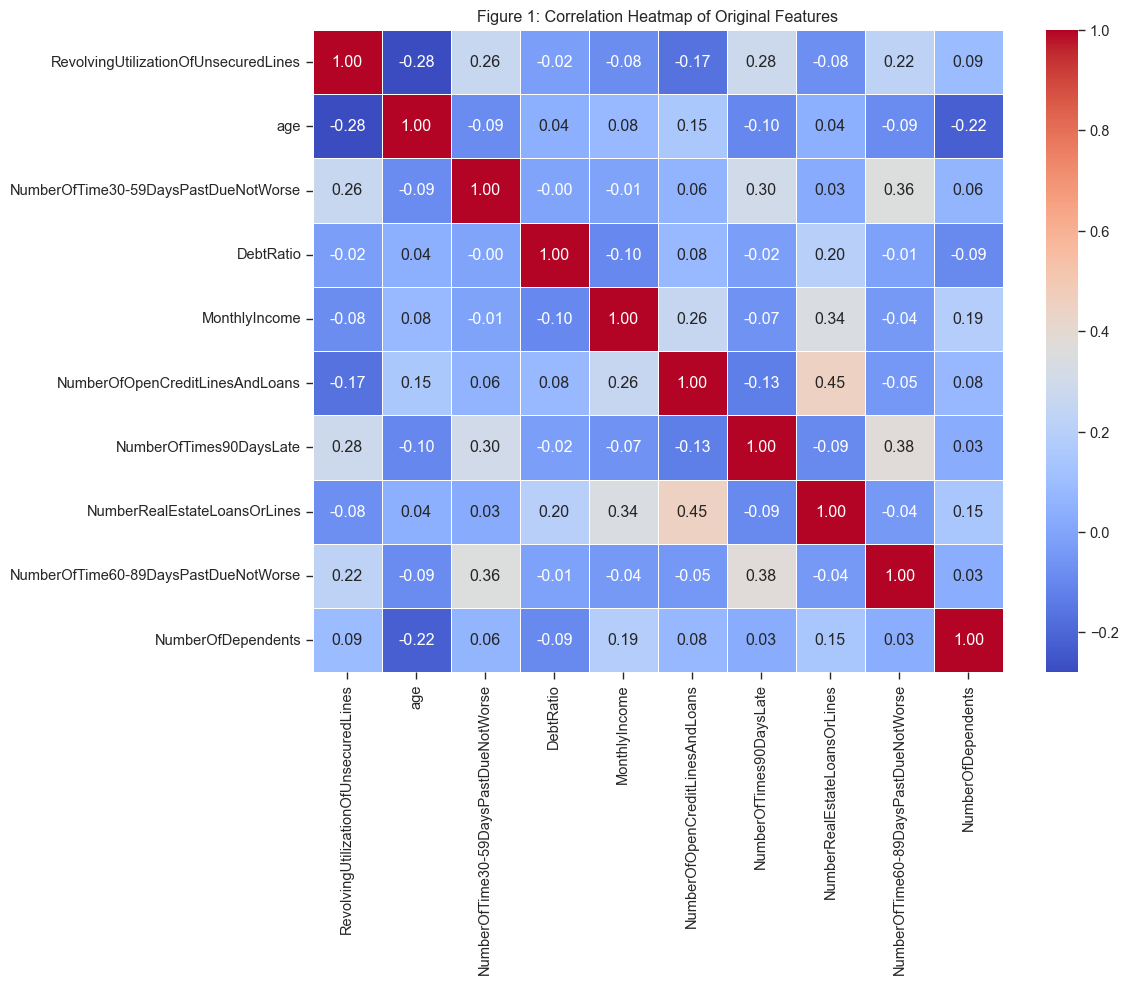

In [43]:
plt.figure(figsize=(12, 10))
corr_matrix = X_full.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Figure 1: Correlation Heatmap of Original Features")
plt.tight_layout()
plt.savefig("fig1_correlation.png", dpi=150)
plt.show()
plt.close()

In [44]:
# 6. SCALING & PCA

In [45]:
print("--- 4. Scaling & PCA ---")
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_full)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X_scaled_full)
print(f"PCA components retained: {pca.n_components_} (95% variance)")

--- 4. Scaling & PCA ---
PCA components retained: 9 (95% variance)


In [46]:
# 7. SAMPLING (TỐI ƯU BỘ NHỚ)

In [47]:
SAMPLE_SIZE = 10000
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(X_pca_full.shape[0], SAMPLE_SIZE, replace=False)

X_final = X_pca_full[sample_indices]
y_true_final = y_true_full.iloc[sample_indices].reset_index(drop=True)
X_original_sample = X_full.iloc[sample_indices].reset_index(drop=True)
print(f"Sampled Shape for Clustering: {X_final.shape}")

Sampled Shape for Clustering: (10000, 9)


In [48]:
# 8. FIGURE 2 & 3: FINDING BEST K

--- 5. Finding Optimal K ---


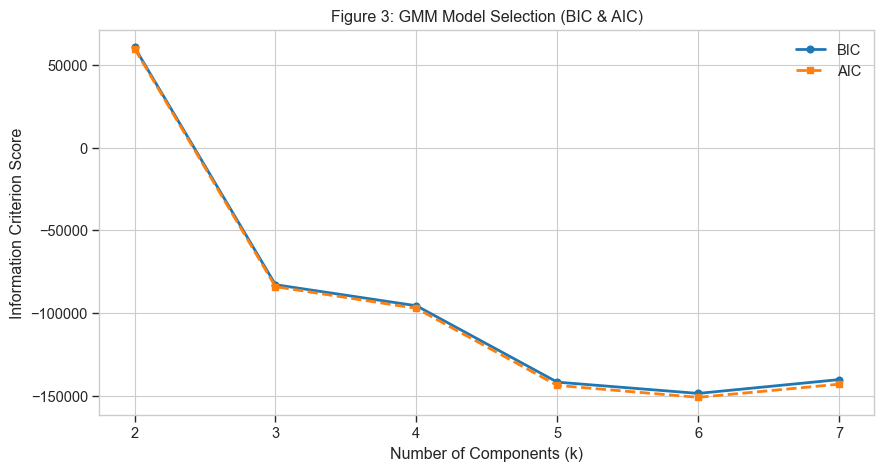

In [49]:
print("--- 5. Finding Optimal K ---")
k_range = range(2, 8)
inertias, silhouettes, bics, aics = [], [], [], []

for k in k_range:
    # KMeans
    kmeans_tmp = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_tmp = kmeans_tmp.fit_predict(X_final)
    inertias.append(kmeans_tmp.inertia_)
    silhouettes.append(silhouette_score(X_final, labels_tmp))
    
    # GMM
    gmm_tmp = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    gmm_tmp.fit(X_final)
    bics.append(gmm_tmp.bic(X_final))
    aics.append(gmm_tmp.aic(X_final))

# Fig 2: KMeans Selection
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color)
ax1.plot(k_range, inertias, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouettes, marker='s', linestyle='--', color=color, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Figure 2: KMeans Optimal K Selection (Elbow & Silhouette)")
fig.tight_layout()
plt.savefig("fig2_kmeans_selection.png", dpi=150)
plt.close()

# Fig 3: GMM Selection
plt.figure(figsize=(10, 5))
plt.plot(k_range, bics, marker='o', label='BIC', linewidth=2)
plt.plot(k_range, aics, marker='s', linestyle='--', label='AIC', linewidth=2)
plt.xlabel('Number of Components (k)')
plt.ylabel('Information Criterion Score')
plt.title("Figure 3: GMM Model Selection (BIC & AIC)")
plt.legend()
plt.savefig("fig3_gmm_selection.png", dpi=150)
plt.show()
plt.close()

In [50]:
# 9. FIGURE B: k-NN DISTANCE (DBSCAN EPS)

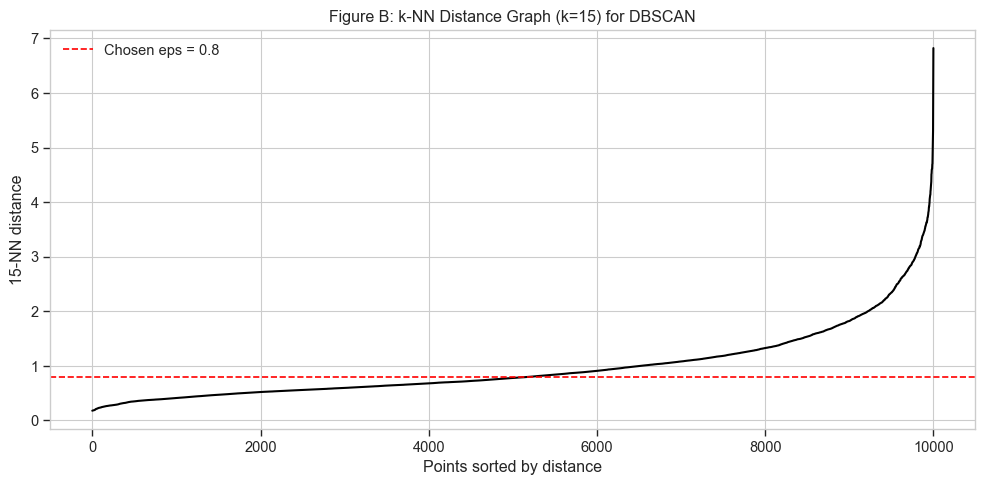

In [51]:
minPts = 15
neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(X_final)
distances, indices = neighbors_fit.kneighbors(X_final)
distances = np.sort(distances[:, minPts-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='black', linewidth=1.5)
plt.title(f"Figure B: k-NN Distance Graph (k={minPts}) for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{minPts}-NN distance")
plt.axhline(y=0.8, color='r', linestyle='--', label='Chosen eps = 0.8')
plt.legend()
plt.tight_layout()
plt.savefig("figB_knn_distance.png", dpi=150)
plt.show()
plt.close()

In [52]:
# 10. RUN FINAL MODELS (K=2)

In [53]:
print("--- 6. Running Final Models (5 Algorithms) ---")
final_results = []
model_labels = {}
K_COMPONENTS = 2

# Danh sách 5 thuật toán
models = {
    'KMeans': KMeans(n_clusters=K_COMPONENTS, n_init=20, random_state=RANDOM_STATE),
    'GMM': GaussianMixture(n_components=K_COMPONENTS, random_state=RANDOM_STATE),
    'Hierarchical': AgglomerativeClustering(n_clusters=K_COMPONENTS),
    'DBSCAN': DBSCAN(eps=0.8, min_samples=15),
    'HDBSCAN': HDBSCAN(min_cluster_size=15, min_samples=10)
}

def evaluate_model(name, X, labels, y_true, runtime):
    mask = labels != -1
    if len(np.unique(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
        ari = adjusted_rand_score(y_true, labels)
    else:
        sil, ari = np.nan, np.nan
    final_results.append({"Model": name, "Silhouette": sil, "ARI": ari, "Time(s)": round(runtime, 4)})

for name, model in models.items():
    start = time.time()
    model_labels[name] = model.fit_predict(X_final)
    evaluate_model(name, X_final, model_labels[name], y_true_final, time.time() - start)

plot_models = list(models.keys()) # Đủ 5 tên: ['KMeans', 'GMM', 'Hierarchical', 'DBSCAN', 'HDBSCAN']

# KMeans
start = time.time()
kmeans = KMeans(n_clusters=K_COMPONENTS, n_init=20, random_state=RANDOM_STATE)
model_labels['KMeans'] = kmeans.fit_predict(X_final)
evaluate_model("KMeans", X_final, model_labels['KMeans'], y_true_final, time.time() - start)

# Hierarchical
start = time.time()
hier = AgglomerativeClustering(n_clusters=K_COMPONENTS)
model_labels['Hierarchical'] = hier.fit_predict(X_final)
evaluate_model("Hierarchical", X_final, model_labels['Hierarchical'], y_true_final, time.time() - start)

# DBSCAN
start = time.time()
dbscan = DBSCAN(eps=np.percentile(distances, 90), min_samples=15)
model_labels['DBSCAN'] = dbscan.fit_predict(X_final)
evaluate_model("DBSCAN", X_final, model_labels['DBSCAN'], y_true_final, time.time() - start)

# GMM
start = time.time()
gmm = GaussianMixture(n_components=K_COMPONENTS, random_state=RANDOM_STATE)
model_labels['GMM'] = gmm.fit_predict(X_final)
evaluate_model("GMM", X_final, model_labels['GMM'], y_true_final, time.time() - start)

# HDBSCAN
from sklearn.cluster import HDBSCAN
start = time.time()
hdb = HDBSCAN(min_cluster_size=15, min_samples=10)
model_labels['HDBSCAN'] = hdb.fit_predict(X_final)
evaluate_model("HDBSCAN", X_final, model_labels['HDBSCAN'], y_true_final, time.time() - start)

--- 6. Running Final Models (5 Algorithms) ---


In [54]:
# 11. FIGURE 4: 2D CLUSTER PROJECTION

--- 7. Generating 5 t-SNE Plots (Better Separation Version) ---


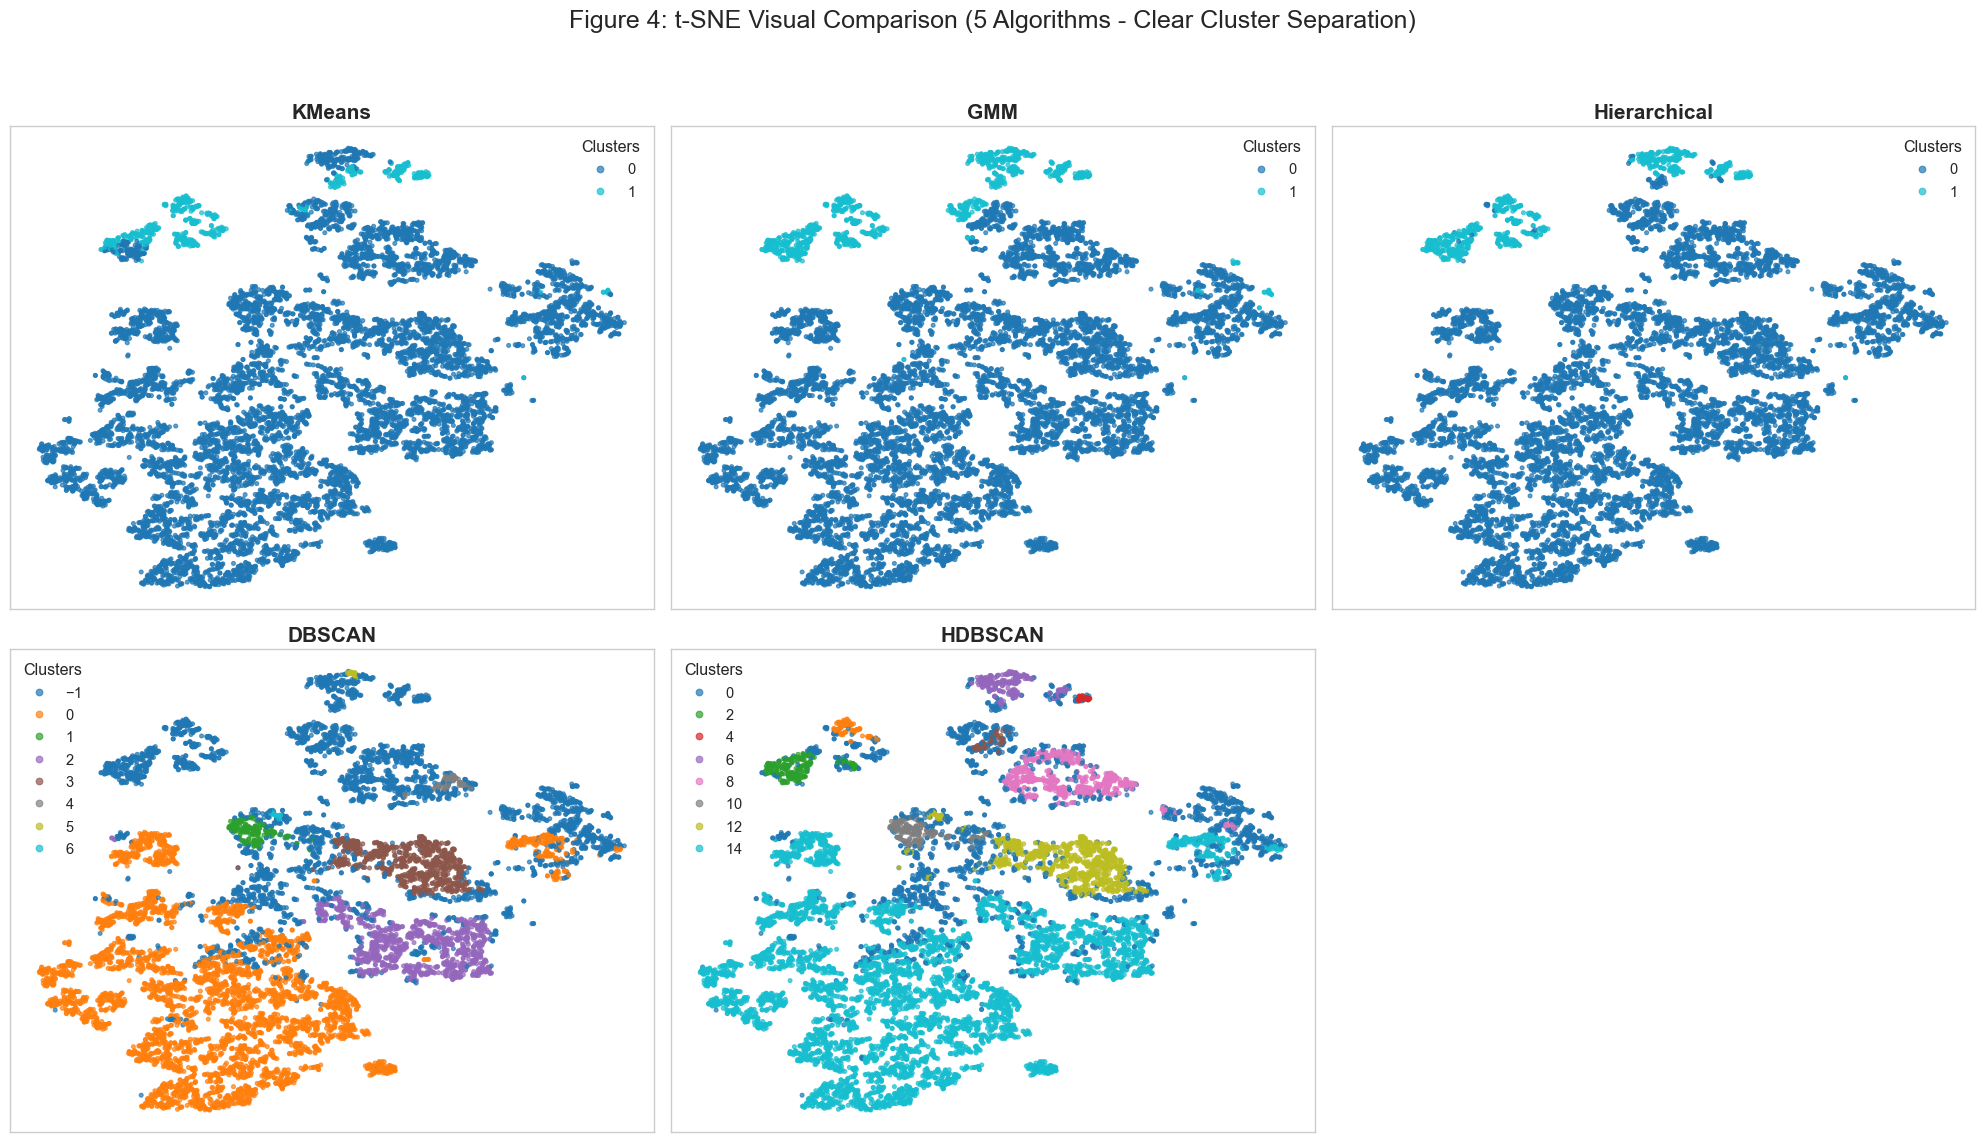

In [59]:
print("--- 7. Generating 5 t-SNE Plots (Better Separation Version) ---")

# Chuẩn hoá dữ liệu trước khi chạy t-SNE (rất quan trọng)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# t-SNE tuning để tách cụm rõ hơn
tsne = TSNE(
    n_components=2,
    perplexity=30,          # 20–40 thường cho kết quả tốt nhất
    learning_rate=800,      # tăng để giảm chồng lấn
    early_exaggeration=80,  # ép cụm tách mạnh hơn
    init='pca',
    max_iter=3000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)


# Vẽ đúng 5 biểu đồ trên lưới 2x3
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, model_name in enumerate(plot_models):

    labels = model_labels[model_name]
    ax = axes[i]

    scatter = ax.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=labels,
        cmap='tab10',      # đổi palette giúp nhìn cụm rõ hơn
        s=8,               # giảm size tránh chồng điểm
        alpha=0.7
    )

    ax.set_title(model_name, fontsize=15, fontweight='bold')
    ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")

    ax.set_xticks([])
    ax.set_yticks([])


# Xoá subplot dư
fig.delaxes(axes[5])


plt.suptitle(
    "Figure 4: t-SNE Visual Comparison (5 Algorithms - Clear Cluster Separation)",
    fontsize=18
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("fig4_tsne_final_fixed.png", dpi=300)
plt.show()

In [ ]:
# 12. FIGURE C: MODEL PERFORMANCE BAR CHART

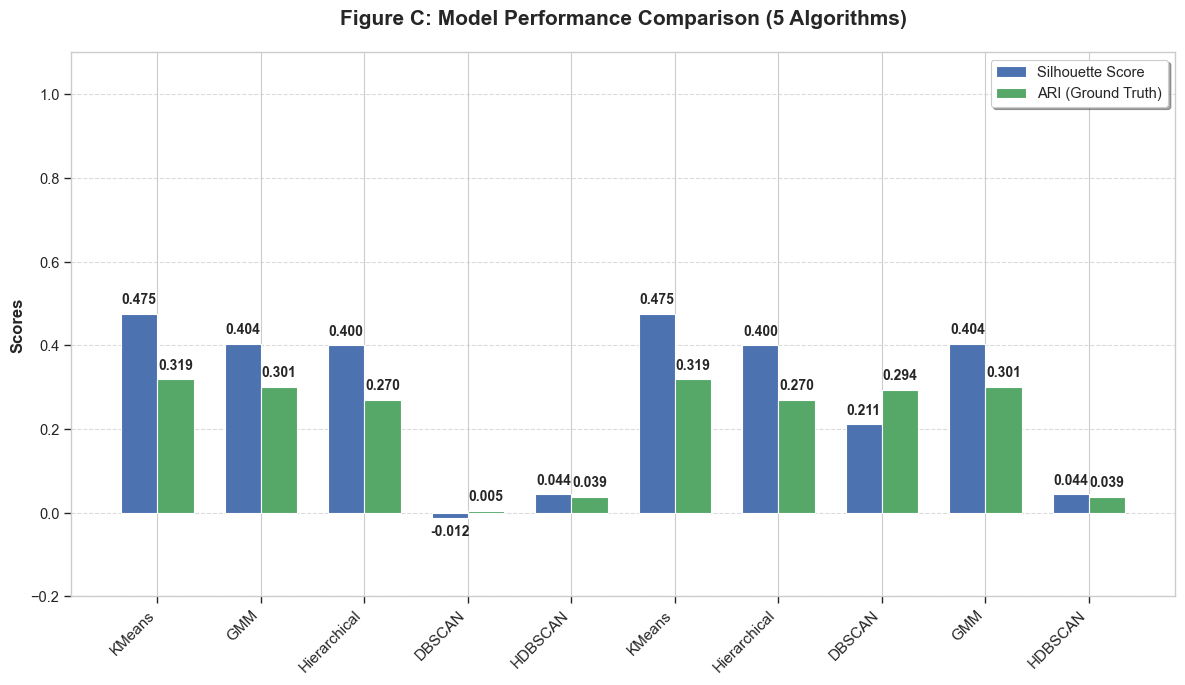

In [ ]:
# Đảm bảo df_metrics đã có đủ 5 model từ bước trước
df_metrics = pd.DataFrame(final_results)
x = np.arange(len(df_metrics['Model']))
width = 0.35  # Độ rộng của mỗi cột

# 1. Tăng figsize để không gian rộng rãi hơn
fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ 2 nhóm cột
rects1 = ax.bar(x - width/2, df_metrics['Silhouette'], width, 
                label='Silhouette Score', color='#4c72b0', edgecolor='white')
rects2 = ax.bar(x + width/2, df_metrics['ARI'], width, 
                label='ARI (Ground Truth)', color='#55a868', edgecolor='white')

# 2. Fix lỗi dính chữ trục X bằng cách xoay 45 độ
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('Figure C: Model Performance Comparison (5 Algorithms)', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Model'], rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right', frameon=True, shadow=True)

# Nới rộng trục Y để không bị chạm chữ trên đầu
ax.set_ylim(-0.2, 1.1) 
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Cải tiến hàm autolabel: giảm fontsize và thêm khoảng cách
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if not np.isnan(height):
            # Nếu giá trị âm thì đặt label bên dưới, dương đặt bên trên
            va = 'bottom' if height >= 0 else 'top'
            xytext = (0, 5) if height >= 0 else (0, -5)
            
            ax.annotate(f'{height:.3f}', 
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=xytext, 
                        textcoords="offset points", 
                        ha='center', va=va,
                        fontsize=10, # Giảm size chữ để không dính nhau
                        fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 4. Sử dụng layout chặt chẽ để không mất chữ khi save
plt.tight_layout()
plt.savefig("figC_model_comparison_fixed.png", dpi=200)
plt.show()

In [ ]:
# 13. FIGURE 5: CLUSTER PROFILING

--- 8. Generating 5 Silhouette Analysis Plots ---


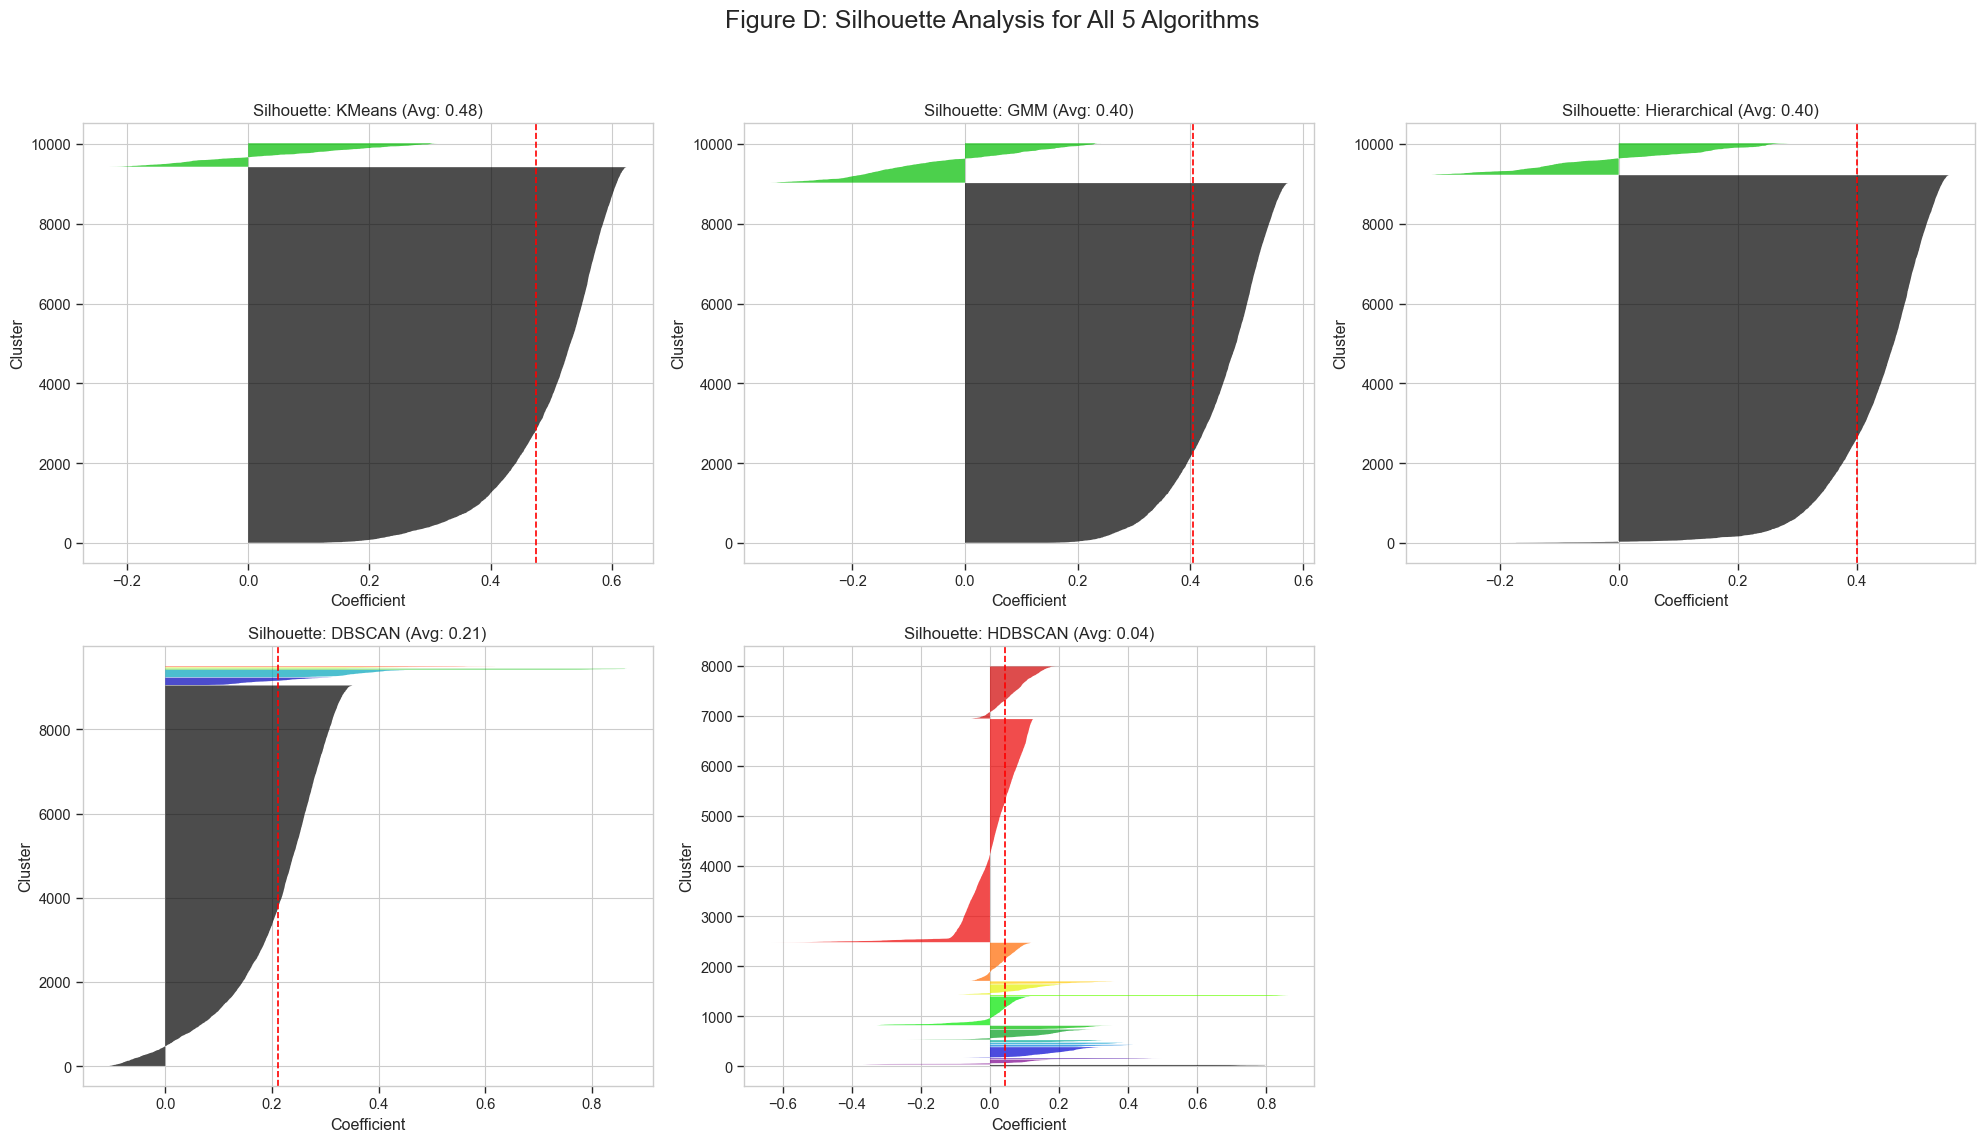

In [ ]:
print("--- 8. Generating 5 Silhouette Analysis Plots ---")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, model_name in enumerate(plot_models):
    labels = model_labels[model_name]
    ax = axes[i]
    mask = labels != -1 
    
    if len(np.unique(labels[mask])) < 2:
        ax.text(0.5, 0.5, f"{model_name}:\nInsufficient clusters", ha='center', va='center')
        continue

    # Tính toán Silhouette cho từng mẫu
    sh_values = silhouette_samples(X_final[mask], labels[mask])
    avg_sh = np.mean(sh_values)
    
    y_lower = 10
    unique_labels = np.unique(labels[mask])
    for j in unique_labels:
        ith_cluster_sh = np.sort(sh_values[labels[mask] == j])
        y_upper = y_lower + ith_cluster_sh.shape[0]
        color = cm.nipy_spectral(float(j) / len(unique_labels))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sh, facecolor=color, alpha=0.7)
        y_lower = y_upper + 10

    ax.set_title(f"Silhouette: {model_name} (Avg: {avg_sh:.2f})", fontsize=12)
    ax.axvline(x=avg_sh, color="red", linestyle="--")
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Cluster")

fig.delaxes(axes[5]) # Xóa ô thừa
plt.suptitle("Figure D: Silhouette Analysis for All 5 Algorithms", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("figD_silhouette_5_models_final.png", dpi=150)
plt.show()

--- 8. Profiling Clusters ---


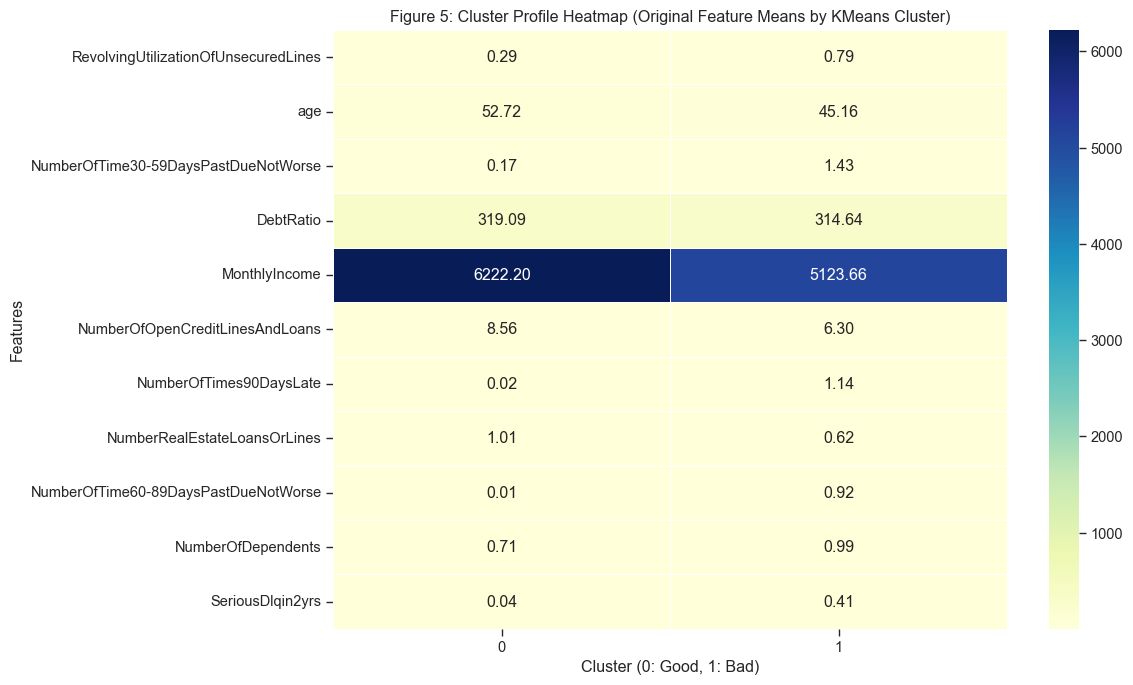

In [ ]:
print("--- 8. Profiling Clusters ---")

df_profile = X_original_sample.copy()
df_profile['Cluster'] = model_labels['KMeans']

# Gán target vào để tính tỷ lệ default theo cluster
df_profile[TARGET_COL] = y_true_final

cluster_profile = df_profile.groupby('Cluster').mean()

plt.figure(figsize=(12, 7))
sns.heatmap(
    cluster_profile.T,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=.5
)

plt.title("Figure 5: Cluster Profile Heatmap (Original Feature Means by KMeans Cluster)")
plt.xlabel("Cluster (0: Good, 1: Bad)")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("fig5_cluster_profile.png", dpi=150)
plt.show()
plt.close()

In [ ]:
# 14. SAVE OUTPUTS TO CSV

In [ ]:
print("--- 9. Saving Final CSVs ---")
df_metrics.to_csv("clustering_metrics_comparison.csv", index=False)

output_sample_df = X_original_sample.copy()
output_sample_df[f"{TARGET_COL}_true"] = y_true_final
for name, labels in model_labels.items():
    output_sample_df[f"label_{name.lower()}"] = labels

output_sample_df.to_excel("Du_Lieu_Tin_Dung_Da_Xu_Ly_Full.xlsx", index=False)

print("\nSUCCESS! All 8 images and 2 CSV files have been generated.")

--- 9. Saving Final CSVs ---

SUCCESS! All 8 images and 2 CSV files have been generated.
